In [1]:
import pandas as pd
import numpy as np

1. Get the Frequency Data

In [2]:
home_dir = "/Users/mariappan.subramanian/OneDrive - The Trade Desk/MMM/Media Parameter Analysis/Dev/"
df_new_clients = pd.read_csv(f"{home_dir}/MMMFeasibility/data/final_data/4_mas_mpa_geo_level_raw_media_data_final_nat.csv")
df_new_clients['AdvertiserName'] = df_new_clients['AdvertiserName'].str.strip().str.replace(' ', '_')
df_old_clients = pd.read_csv(f"{home_dir}/MDF/MDF_May30_Channel_events.csv")

In [3]:
# remove the 'common clients' from the old data
old_clients = df_old_clients['AdvertiserName'].unique()
new_clients = df_new_clients['AdvertiserName'].unique()
common_clients = set(old_clients).intersection(new_clients)
df_old_clients = df_old_clients[~df_old_clients['AdvertiserName'].isin(common_clients)].reset_index(drop=True)

In [4]:
# frequency data for H1 brands
freq_h1_brands = df_old_clients[['WES', 'AdvertiserName', 'Display_FPP', 'TV_FPP', 'Video_FPP']].replace(0, np.nan)

In [5]:
# frequency data for new brands
freq_new_brands = df_new_clients.pivot_table(
  index=['WES', 'AdvertiserName'],
  columns='Channel',
  values='Frequency Per Person',
  aggfunc='mean'
).reset_index().rename(
  columns={'Display': 'Display_FPP', 'TV': 'TV_FPP', 'Video': 'Video_FPP'}
)[['WES', 'AdvertiserName', 'Display_FPP', 'TV_FPP', 'Video_FPP']]


In [6]:
freq_df_full = pd.concat([freq_new_brands, freq_h1_brands]).reset_index(drop=True)

In [7]:
advertiser_list = [
  'ALDI_US_Starcom',
  'Allergan',
  'Audi',
  'Burger_King',
  'Chick-Fil-A',
  'Chumba_Casino',
  'Huntington_National_Bank',
  'Hyundai',
  'IBM_-_US',
  'Intuit_-_Quickbooks',
  'Live_Nation_MasterAdvertiser',
  'Mattress_Firm_US_Mediavest',
  'Mazda',
  'Meijer',
  'MRG_Chevy_LMA',
  'Popeyes',
  'Progressive_Insurance',
  'Samsung_US_Starcom'
]

for advertiser in advertiser_list:
  if advertiser not in freq_df_full['AdvertiserName'].unique():
    print(advertiser)


freq_df_full_filtered = freq_df_full[freq_df_full['AdvertiserName'].isin(advertiser_list)]

2. Historical Median Frequency

In [24]:
# get the median frequency by advertiser, channel
median_freq_df = freq_df_full_filtered.groupby('AdvertiserName').median(numeric_only=True).replace(0, np.nan).clip(lower=1.0)
median_freq_df. \
  rename(columns={'Display_FPP': 'Display', 'TV_FPP': 'TV', 'Video_FPP': 'Video'}, inplace=True)
median_freq_df

,Display,TV,Video
AdvertiserName,,,
ALDI_US_Starcom,3.5,4.20,3.50
Allergan,2.7,2.30,2.00
Audi,2.4,2.00,1.80
Burger_King,4.3,3.70,1.50
Chick-Fil-A,NaN,3.10,1.30
Chumba_Casino,8.5,8.10,9.60
Huntington_National_Bank,1.1,2.20,1.85
Hyundai,2.1,3.00,2.30
IBM_-_US,1.6,2.95,4.10


3. Prior Median Frequency

In [27]:
# prior frequency for each channel
prior_frequency_values = {
  # "Audio": 10.0,
  "Display": 13.0,
  # "NativeDisplay": 20.0,
  "TV": 3.0,
  "Video": 5.0
}

prior_freq_df = pd.DataFrame(
  data=[prior_frequency_values] * median_freq_df.shape[0],
  index=median_freq_df.index
  )

prior_freq_df

,Display,TV,Video
AdvertiserName,,,
ALDI_US_Starcom,13.0,3.0,5.0
Allergan,13.0,3.0,5.0
Audi,13.0,3.0,5.0
Burger_King,13.0,3.0,5.0
Chick-Fil-A,13.0,3.0,5.0
Chumba_Casino,13.0,3.0,5.0
Huntington_National_Bank,13.0,3.0,5.0
Hyundai,13.0,3.0,5.0
IBM_-_US,13.0,3.0,5.0


4. Prior Freq to Median Freq Ratio

In [29]:
prior_median_multiplier = prior_freq_df[median_freq_df.columns] / median_freq_df
prior_median_multiplier

,Display,TV,Video
AdvertiserName,,,
ALDI_US_Starcom,3.714286,0.714286,1.428571
Allergan,4.814815,1.304348,2.500000
Audi,5.416667,1.500000,2.777778
Burger_King,3.023256,0.810811,3.333333
Chick-Fil-A,NaN,0.967742,3.846154
Chumba_Casino,1.529412,0.370370,0.520833
Huntington_National_Bank,11.818182,1.363636,2.702703
Hyundai,6.190476,1.000000,2.173913
IBM_-_US,8.125000,1.016949,1.219512


In [34]:
prior_median_multiplier_dict = prior_median_multiplier.round(2).to_dict(orient='index')
prior_median_multiplier_dict

{'ALDI_US_Starcom': {'Display': 3.71, 'TV': 0.71, 'Video': 1.43},
 'Allergan': {'Display': 4.81, 'TV': 1.3, 'Video': 2.5},
 'Audi': {'Display': 5.42, 'TV': 1.5, 'Video': 2.78},
 'Burger_King': {'Display': 3.02, 'TV': 0.81, 'Video': 3.33},
 'Chick-Fil-A': {'Display': nan, 'TV': 0.97, 'Video': 3.85},
 'Chumba_Casino': {'Display': 1.53, 'TV': 0.37, 'Video': 0.52},
 'Huntington_National_Bank': {'Display': 11.82, 'TV': 1.36, 'Video': 2.7},
 'Hyundai': {'Display': 6.19, 'TV': 1.0, 'Video': 2.17},
 'IBM_-_US': {'Display': 8.12, 'TV': 1.02, 'Video': 1.22},
 'Intuit_-_Quickbooks': {'Display': 10.83, 'TV': 1.2, 'Video': 5.0},
 'Live_Nation_MasterAdvertiser': {'Display': 8.12, 'TV': 1.76, 'Video': 2.94},
 'MRG_Chevy_LMA': {'Display': 2.83, 'TV': 0.53, 'Video': 1.56},
 'Mattress_Firm_US_Mediavest': {'Display': nan, 'TV': 1.11, 'Video': 2.0},
 'Mazda': {'Display': 5.65, 'TV': 1.15, 'Video': 3.57},
 'Meijer': {'Display': 8.67, 'TV': 0.88, 'Video': 5.0},
 'Popeyes': {'Display': 3.25, 'TV': 1.5, 'Vide

3.5121796559010354, 0.9344209921548972


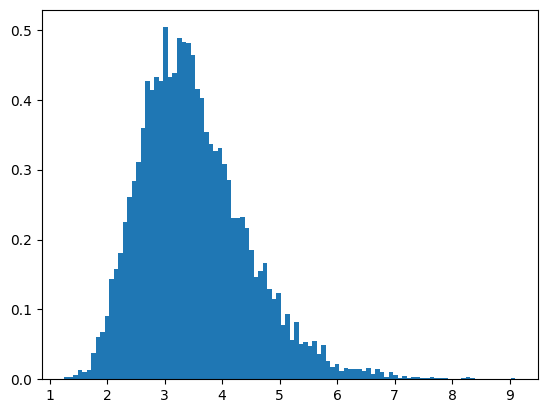

In [49]:
import matplotlib.pyplot as plt
import tensorflow_probability as tfp

mu = 3.5
dev = np.log(1.3)
ln_mu = np.log(mu) - (dev ** 2 / 2)

log_norm = tfp.distributions.LogNormal(loc=ln_mu, scale=dev)
samples = log_norm.sample(10000).numpy()
print(f'{samples.mean()}, {samples.std()}')

plt.hist(samples, bins=100, density=True)
plt.show()

In [67]:
np.array([1, 2, 3]) * 0.3

array([0.3, 0.6, 0.9])

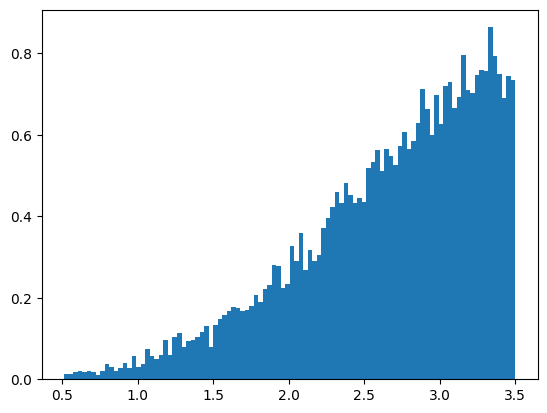

In [65]:
trunc_norm = tfp.distributions.TruncatedNormal(loc=mu, scale=0.3 * mu, low=0.5, high=mu)
trunc_norm_samples = trunc_norm.sample(10000).numpy()
plt.hist(trunc_norm_samples, bins=100, density=True)
plt.show()


In [62]:
trunc_norm_samples.mean(), trunc_norm_samples.std()

(np.float32(2.6684031), np.float32(0.6263812))

In [50]:
print(f'{ln_mu}, {dev}')

1.2183454648605843, 0.26236426446749106


In [ ]:
?tfp.distributions.TruncatedNormal

Init signature:
tfp.distributions.TruncatedNormal(
    loc,
    scale,
    low,
    high,
    validate_args=False,
    allow_nan_stats=True,
    name='TruncatedNormal',
)
Docstring:     
The Truncated Normal distribution.

The truncated normal is a normal distribution bounded between `low`
and `high` (the pdf is 0 outside these bounds and renormalized).

Samples from this distribution are differentiable with respect to `loc`,
`scale` as well as the bounds, `low` and `high`, i.e., this
implementation is fully reparameterized.

For more details, see [here](
https://en.wikipedia.org/wiki/Truncated_normal_distribution).

### Mathematical Details

The probability density function (pdf) of this distribution is:
```none
  pdf(x; loc, scale, low, high) =
      { (2 pi)**(-0.5) exp(-0.5 y**2) / (scale * z) for low <= x <= high
      { 0                                    otherwise
  y = (x - loc)/scale
  z = NormalCDF((high - loc) / scale) - NormalCDF((low - loc) / scale)
```

where:

* `Normal